# New Hybrid Training v4 — multi-seed, CIs, per-class summary


| **1** | **Multi-seed runs** | Each method runs across `SEEDS = [42, 123, 456]`. Results are reported as `mean ± std`. |
| **3** | **Confidence intervals** | Headline numbers now include std across seeds. The summary table reports `acc ± std`. |
| **4** | **Per-class summary** | Section 17 includes a methods × classes heatmap of mean F1 per label %. |


**Workflow:** 0–4 once → 9 once (SimCLR pretrain) → for each `LABEL_PCT` ∈ {0.20, 0.40, 0.01}: run sections 10–16 → finally run section 17.

> 

## Section 0 — Environment Check

In [1]:
# Section 0: Environment check
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import sys
import platform

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")

if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:  {torch.version.cuda}")
elif torch.backends.mps.is_available():
    device = "mps"
    print(f"Device:        Apple MPS (Metal)")
else:
    device = "cpu"
    print(f"Device:        CPU (training will be slow)")

print(f"Selected device: {device}")

Python:        3.13.9
PyTorch:       2.11.0
Torchvision:   0.26.0
Device:        Apple MPS (Metal)
Selected device: mps


## Section 1 — Paths & `RESULTS/` folder

```
RESULTS/
├── integrity/
├── splits/
├── simclr/
├── 1pct/
│   ├── B1_supervised/
│   │   ├── seed_42/         # per-seed metrics, figures, checkpoint
│   │   ├── seed_123/
│   │   ├── seed_456/
│   │   └── aggregate.json   # mean ± std across seeds
│   ├── B3_self_supervised/
│   ├── B4_semi_supervised/
│   ├── B5_hybrid/
│   ├── overfitting/
│   └── pct_summary.json
├── 20pct/, 40pct/
└── summary/                  # cross-percentage view
    ├── all_results.json
    ├── comparison_chart.png  # bar chart with error bars
    └── per_class_heatmap_<pct>.png
```

In [2]:
import os

# ============================================================
# EDIT THESE TWO PATHS ONLY
# ============================================================
TOMATO_PATH = "/Users/sherry/Desktop/Tomato_Disease/DATASET"
PROJECT_DIR = "/Users/sherry/Desktop/Tomato_Disease"
# ============================================================

RESULTS_DIR = f"{PROJECT_DIR}/RESULTS_2.0"
os.makedirs(f"{RESULTS_DIR}/integrity", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/splits", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/simclr", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/summary", exist_ok=True)
for pct in ["1pct", "20pct", "40pct"]:
    os.makedirs(f"{RESULTS_DIR}/{pct}/overfitting", exist_ok=True)
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        os.makedirs(f"{RESULTS_DIR}/{pct}/{method}", exist_ok=True)
print(f"RESULTS tree ready under: {RESULTS_DIR}")

assert os.path.isdir(TOMATO_PATH), f"Dataset not found at {TOMATO_PATH}"
tomato_classes = sorted([d for d in os.listdir(TOMATO_PATH)
                         if os.path.isdir(os.path.join(TOMATO_PATH, d))])
print(f"\nFound {len(tomato_classes)} class folder(s):")
total = 0
for c in tomato_classes:
    n = len(os.listdir(os.path.join(TOMATO_PATH, c)))
    total += n
    print(f"  {c:<50} {n:>5}")
print(f"  {'TOTAL':<50} {total:>5}")

RESULTS tree ready under: /Users/sherry/Desktop/Tomato_Disease/RESULTS_2.0

Found 10 class folder(s):
  Tomato_Bacterial_spot                               2127
  Tomato_Early_blight                                 1000
  Tomato_Late_blight                                  1909
  Tomato_Leaf_Mold                                     952
  Tomato_Septoria_leaf_spot                           1771
  Tomato_Spider_mites_Two_spotted_spider_mite         1676
  Tomato__Target_Spot                                 1404
  Tomato__Tomato_YellowLeaf__Curl_Virus               3208
  Tomato__Tomato_mosaic_virus                          373
  Tomato_healthy                                      1591
  TOTAL                                              16011


## Section 2 — Hyperparameters

One new constant from v3: `SEEDS = [42, 123, 456]`. Each one builds a different split
*and* a different model init, so the std across them reflects total pipeline noise.

In [3]:
import torch

# === SPLIT RATIOS ===
VAL_PCT   = 0.10
# LABEL_PCT defined in Section 10. Unlabeled = whatever's left.

# === MULTI-SEED ===
SEEDS = [42, 123, 456]   # each method runs once per seed

# === TRAINING ===
IMG_SIZE       = 224
BATCH_SIZE     = 128
NUM_WORKERS    = 0    # 0 is safest on macOS/MPS

# SimCLR
SIMCLR_EPOCHS  = 10
LR_SIMCLR      = 1e-4
SIMCLR_TEMP    = 0.5

# MixMatch
K_AUGMENTS      = 2
SHARPEN_TEMP    = 0.5
MIXUP_ALPHA     = 0.75
LAMBDA_U        = 1.0

# Per-method learning rates
LR_SUP          = 1e-3   # B1
LR_FT           = 1e-4   # B3
LR_MM           = 1e-4   # B4
LR_HYBRID       = 1e-4   # B5

EPOCHS_DEFAULT  = 30

# SimCLR pretraining seed is separate (and fixed) — runs once across all experiments
SIMCLR_SEED     = 42

print(f"Device: {device}")
print(f"VAL_PCT: {VAL_PCT}  BATCH_SIZE: {BATCH_SIZE}")
print(f"SEEDS for method runs: {SEEDS}")
print(f"LRs — B1: {LR_SUP}  B3: {LR_FT}  B4: {LR_MM}  B5: {LR_HYBRID}")

Device: mps
VAL_PCT: 0.1  BATCH_SIZE: 128
SEEDS for method runs: [42, 123, 456]
LRs — B1: 0.001  B3: 0.0001  B4: 0.0001  B5: 0.0001


## Section 3 — Imports, utilities, base dataset

In [4]:
import random
import numpy as np
import json
import copy
import time
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm import tqdm
from collections import Counter


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def empty_cache():
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()


base_dataset = ImageFolder(root=TOMATO_PATH)
NUM_CLASSES = len(base_dataset.classes)
print(f"Classes ({NUM_CLASSES}):")
for i, c in enumerate(base_dataset.classes):
    print(f"  {i}: {c}")

Classes (10):
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy


## Section 4 — Dataset integrity check (run ONCE)

Read-only — only **reports** on the dataset, never modifies it (class balance is preserved).
Same as v3.

In [5]:
import hashlib
from collections import defaultdict

INTEGRITY_PATH = f"{RESULTS_DIR}/integrity/report.json"

if os.path.exists(INTEGRITY_PATH):
    with open(INTEGRITY_PATH) as f:
        integrity = json.load(f)
    print(f"Loaded cached integrity report from {INTEGRITY_PATH}")
    print("(delete the file to recompute)\n")
else:
    print("Running integrity check on dataset (one-time, ~30-60s)...")
    hashes = defaultdict(list)
    corrupt = []
    sizes_kb = []
    for idx, (path, label) in enumerate(tqdm(base_dataset.samples, desc="Hashing")):
        try:
            with open(path, "rb") as f:
                data = f.read()
            h = hashlib.md5(data).hexdigest()
            hashes[h].append({"idx": idx, "path": path, "label": int(label),
                              "class": base_dataset.classes[label]})
            sizes_kb.append(len(data) / 1024)
        except Exception as e:
            corrupt.append({"idx": idx, "path": path, "error": str(e)})

    print("Verifying images are loadable...")
    for idx, (path, label) in enumerate(tqdm(base_dataset.samples, desc="Verifying")):
        try:
            Image.open(path).convert("RGB").load()
        except Exception as e:
            corrupt.append({"idx": idx, "path": path, "error": f"PIL: {e}"})

    duplicate_groups = {h: v for h, v in hashes.items() if len(v) > 1}
    cross_class_dups = []
    same_class_dups = 0
    for h, group in duplicate_groups.items():
        labels_in_group = set(item["label"] for item in group)
        if len(labels_in_group) > 1:
            cross_class_dups.append({"hash": h, "files": group})
        else:
            same_class_dups += len(group) - 1

    class_counts = Counter(label for _, label in base_dataset.samples)
    class_balance = {base_dataset.classes[c]: n for c, n in sorted(class_counts.items())}
    counts = list(class_balance.values())
    imbalance_ratio = max(counts) / max(min(counts), 1)

    integrity = {
        "total_files": len(base_dataset.samples),
        "unique_hashes": len(hashes),
        "duplicate_groups": len(duplicate_groups),
        "duplicate_files_total": sum(len(v) for v in duplicate_groups.values()),
        "same_class_duplicate_extras": same_class_dups,
        "cross_class_duplicate_groups": len(cross_class_dups),
        "cross_class_duplicate_examples": cross_class_dups[:10],
        "corrupt_files": corrupt,
        "class_balance": class_balance,
        "imbalance_ratio_max_to_min": imbalance_ratio,
        "size_kb_mean": float(np.mean(sizes_kb)) if sizes_kb else 0.0,
        "size_kb_std":  float(np.std(sizes_kb))  if sizes_kb else 0.0,
    }
    with open(INTEGRITY_PATH, "w") as f:
        json.dump(integrity, f, indent=2)

print("=" * 72)
print("DATASET INTEGRITY REPORT")
print("=" * 72)
print(f"Total files:                 {integrity['total_files']}")
print(f"Unique hashes:               {integrity['unique_hashes']}")
print(f"Duplicate groups:            {integrity['duplicate_groups']}")
print(f"Total duplicate files:       {integrity['duplicate_files_total']}")
print(f"  - same class duplicates:   {integrity['same_class_duplicate_extras']}")
print(f"  - CROSS-CLASS dup groups:  {integrity['cross_class_duplicate_groups']}")
print(f"Corrupt / unreadable files:  {len(integrity['corrupt_files'])}")
print(f"Imbalance ratio (max/min):   {integrity['imbalance_ratio_max_to_min']:.2f}x")
print()
print("Class balance (preserved as-is — no oversampling/undersampling applied):")
for cname, n in integrity["class_balance"].items():
    print(f"  {cname:<50} {n:>5}")

print()
print("-" * 72)
print("VERDICT")
print("-" * 72)
issues = []
if integrity["cross_class_duplicate_groups"] > 0:
    issues.append(f"CRITICAL — {integrity['cross_class_duplicate_groups']} cross-class "
                  f"duplicate groups will leak labels across splits. De-duplicate.")
if integrity["same_class_duplicate_extras"] > integrity["total_files"] * 0.05:
    issues.append(f"WARNING — {integrity['same_class_duplicate_extras']} same-class "
                  f"duplicates may inflate val accuracy.")
if len(integrity["corrupt_files"]) > 0:
    issues.append(f"WARNING — {len(integrity['corrupt_files'])} corrupt files.")
if integrity["imbalance_ratio_max_to_min"] > 5:
    issues.append(f"NOTE — Class imbalance is {integrity['imbalance_ratio_max_to_min']:.1f}x. "
                  f"Report macro F1 + per-class metrics (already done automatically).")

if not issues:
    print("✓ No major issues found.")
else:
    for msg in issues:
        print(f"⚠ {msg}")
print("=" * 72)

Running integrity check on dataset (one-time, ~30-60s)...


Hashing: 100%|██████████| 16011/16011 [00:02<00:00, 6140.89it/s]


Verifying images are loadable...


Verifying: 100%|██████████| 16011/16011 [00:03<00:00, 5247.11it/s]

DATASET INTEGRITY REPORT
Total files:                 16011
Unique hashes:               15997
Duplicate groups:            14
Total duplicate files:       28
  - same class duplicates:   14
  - CROSS-CLASS dup groups:  0
Corrupt / unreadable files:  0
Imbalance ratio (max/min):   8.60x

Class balance (preserved as-is — no oversampling/undersampling applied):
  Tomato_Bacterial_spot                               2127
  Tomato_Early_blight                                 1000
  Tomato_Late_blight                                  1909
  Tomato_Leaf_Mold                                     952
  Tomato_Septoria_leaf_spot                           1771
  Tomato_Spider_mites_Two_spotted_spider_mite         1676
  Tomato__Target_Spot                                 1404
  Tomato__Tomato_YellowLeaf__Curl_Virus               3208
  Tomato__Tomato_mosaic_virus                          373
  Tomato_healthy                                      1591

-----------------------------------------------

## Section 5 — Transforms & dataset wrappers

Same as v3. `weak_transform` (with augmentation) drives training; `eval_transform`
(deterministic) drives val and clean-train measurement.

In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
weak_transform = train_transform

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class LabeledSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


class UnlabeledKAug(Dataset):
    def __init__(self, base_dataset, indices, transform, K=2):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
        self.K = K
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, _ = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return [self.transform(img) for _ in range(self.K)]


class SimCLRDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.base = ImageFolder(root=root_dir)
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        path, _ = self.base.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), self.transform(img)


def sharpen(p, T=0.5):
    p = p.pow(1.0 / T)
    return p / p.sum(dim=1, keepdim=True)


def mixup(x1, y1, x2, y2, alpha=0.75):
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    x_mix = lam * x1 + (1 - lam) * x2
    y_mix = lam * y1 + (1 - lam) * y2
    return x_mix, y_mix

print("Transforms and dataset wrappers ready.")

Transforms and dataset wrappers ready.


## Section 6 — 3-way stratified split

Returns **labeled / unlabeled / val**. Same as v3. Floor of `min_per_class` images per
class in labeled and val sets.

In [7]:
def stratified_split_with_floor(dataset, label_pct, val_pct,
                                 min_per_class=10, seed=42):
    """
    Per-class stratified split into (labeled, unlabeled, val).
    Guarantees min_per_class images in labeled and val sets.
    Unlabeled = whatever is left over.
    """
    rng = random.Random(seed)
    class_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset.samples[idx]
        class_indices.setdefault(label, []).append(idx)

    labeled_idx, unlabeled_idx, val_idx = [], [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n = len(indices)
        n_label = max(min_per_class, int(label_pct * n))
        n_val   = max(min_per_class, int(val_pct * n))
        labeled_idx.extend(indices[:n_label])
        val_idx.extend(indices[n_label:n_label + n_val])
        unlabeled_idx.extend(indices[n_label + n_val:])
    return labeled_idx, unlabeled_idx, val_idx

print("Split function defined.")

Split function defined.


## Section 7 — Metrics & evaluation utilities

Same `full_evaluation` as v3, with one tweak: it accepts a `seed=` parameter so per-seed
output folders are clearly labelled.

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, sub, fmt in [(axes[0], cm,      "Counts",     "d"),
                              (axes[1], cm_norm, "Normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues", aspect="auto")
        ax.set_title(f"{title} — {sub}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels([c[:20] for c in class_names], rotation=45, ha="right")
        ax.set_yticklabels([c[:20] for c in class_names])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                color = "white" if val > mat.max() * 0.55 else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        color=color, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_training_curves(history, save_path, method_name):
    epochs = history.get("epoch", [])
    has_lx = "loss_x" in history
    has_train_acc = "train_acc" in history and len(history["train_acc"]) > 0
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if has_lx:
        axes[0].plot(epochs, history["loss_x"], marker="o", label="labeled (lx)")
        axes[0].plot(epochs, history["loss_u"], marker="s", label="unlabeled (lu)")
    else:
        axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{method_name} — training loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    if has_train_acc:
        axes[1].plot(epochs, history["train_acc"], marker="o",
                     color="tab:blue", label="train", linewidth=2)
        axes[1].plot(epochs, history["val_acc"], marker="s",
                     color="tab:green", label="val", linewidth=2)
        axes[1].fill_between(epochs, history["train_acc"], history["val_acc"],
                              alpha=0.15, color="tab:red", label="gap")
        if epochs:
            final_gap = history["train_acc"][-1] - history["val_acc"][-1]
            axes[1].text(0.02, 0.05, f"Final gap: {final_gap:+.2f}%",
                          transform=axes[1].transAxes, fontsize=10,
                          verticalalignment="bottom",
                          bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
        axes[1].legend(loc="lower right")
    else:
        axes[1].plot(epochs, history["val_acc"], marker="o", color="tab:green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{method_name} — accuracy")
    axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_per_class_bars(per_class, class_names, save_path, method_name):
    n = len(class_names)
    x = np.arange(n); w = 0.2
    fig, ax = plt.subplots(figsize=(max(12, n * 1.1), 6))
    ax.bar(x - 1.5*w, per_class["accuracy"],  w, label="Accuracy")
    ax.bar(x - 0.5*w, per_class["precision"], w, label="Precision")
    ax.bar(x + 0.5*w, per_class["recall"],    w, label="Recall")
    ax.bar(x + 1.5*w, per_class["f1"],        w, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
    ax.set_title(f"{method_name} — per-class metrics")
    ax.legend(loc="lower right"); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def full_evaluation(model, loader, class_names, method_name, history,
                    out_dir, pct_tag, seed=None, model_state=None):
    """Evaluate `model` on `loader` and save everything to `out_dir`."""
    os.makedirs(out_dir, exist_ok=True)
    y_true, y_pred = collect_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    row_sum = cm.sum(axis=1).clip(min=1)
    acc_cls = cm.diagonal() / row_sum

    per_class = {
        "class_names": list(class_names),
        "accuracy":   acc_cls.tolist(),
        "precision":  p_cls.tolist(),
        "recall":     r_cls.tolist(),
        "f1":         f1_cls.tolist(),
        "support":    support.tolist(),
    }
    metrics = {
        "method": method_name, "pct_tag": pct_tag, "seed": seed,
        "overall": {
            "accuracy":         float(acc),
            "precision_macro":  float(p_macro),
            "recall_macro":     float(r_macro),
            "f1_macro":         float(f1_macro),
            "precision_weighted": float(p_weight),
            "recall_weighted":    float(r_weight),
            "f1_weighted":        float(f1_weight),
        },
        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
        "history": history,
        "best_val_acc": max(history.get("val_acc", [0.0])),
        "final_train_acc": history["train_acc"][-1] if history.get("train_acc") else None,
        "final_val_acc":   history["val_acc"][-1]   if history.get("val_acc")   else None,
    }
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    report = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, digits=4, zero_division=0)
    with open(f"{out_dir}/classification_report.txt", "w") as f:
        f.write(f"Method: {method_name}   Label %: {pct_tag}   Seed: {seed}\n")
        f.write("=" * 80 + "\n")
        f.write(report)
        f.write("\n\nConfusion matrix (rows=true, cols=pred):\n")
        f.write(str(cm))

    title_suffix = f" @ {pct_tag} (seed={seed})" if seed is not None else f" @ {pct_tag}"
    plot_confusion_matrix(cm, class_names,
        f"{out_dir}/confusion_matrix.png", title=f"{method_name}{title_suffix}")
    plot_training_curves(history,
        f"{out_dir}/training_curves.png", f"{method_name}{title_suffix}")
    plot_per_class_bars(per_class, class_names,
        f"{out_dir}/per_class_metrics.png", method_name=f"{method_name}{title_suffix}")

    state = model_state if model_state is not None else model.state_dict()
    torch.save({"state_dict": state, "method": method_name, "seed": seed,
                "pct_tag": pct_tag, "history": history},
               f"{out_dir}/checkpoint.pth")

    print(f"  [seed {seed}] val acc: {acc*100:.2f}%   macro F1: {f1_macro*100:.2f}%   "
          f"weighted F1: {f1_weight*100:.2f}%")
    return metrics

print("Metrics utilities loaded.")

Metrics utilities loaded.


## Section 8 — SimCLR model & loss

In [9]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128, init="imagenet"):
        super().__init__()
        if init == "imagenet":
            weights = models.ResNet18_Weights.IMAGENET1K_V1
        elif init == "random":
            weights = None
        else:
            raise ValueError(f"Unknown init: {init}")
        self.encoder = models.resnet18(weights=weights)
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )
    def forward(self, x):
        h = self.encoder(x); z = self.projector(h)
        return h, z


def nt_xent_loss(z_i, z_j, temperature=SIMCLR_TEMP):
    B = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -9e15)
    positives = torch.cat([torch.diag(sim,  B), torch.diag(sim, -B)], dim=0)
    denominator = torch.logsumexp(sim, dim=1)
    return (-positives + denominator).mean()

print("SimCLR model + NT-Xent loss defined.")

SimCLR model + NT-Xent loss defined.


## Section 9 — SimCLR pretraining (run ONCE — cached)

Trains SimCLR on the entire dataset (labels ignored). Uses `SIMCLR_SEED` (fixed, not the
method seeds). Cached on disk. All B3 and B5 seed runs share this single SimCLR encoder.

SSL dataset: 16011 images, 125 batches/epoch
SimCLR fine-tune from ImageNet: 10 epochs (seed=42)
Batch: 128  LR: 0.0001  Temp: 0.5


SimCLR 1/10:   0%|          | 0/125 [00:00<?, ?it/s]/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
SimCLR 1/10: 100%|██████████| 125/125 [06:26<00:00,  3.10s/it, loss=3.8881]


  Epoch 1/10  loss=4.0737  time=6.4min


SimCLR 2/10: 100%|██████████| 125/125 [07:23<00:00,  3.55s/it, loss=3.8119]


  Epoch 2/10  loss=3.8343  time=7.4min


...

  Epoch 8/10  loss=3.7296  time=7.3min


SimCLR 9/10: 100%|██████████| 125/125 [07:18<00:00,  3.51s/it, loss=3.7104]


  Epoch 9/10  loss=3.7229  time=7.3min


SimCLR 10/10: 100%|██████████| 125/125 [07:19<00:00,  3.52s/it, loss=3.7202]


  Epoch 10/10  loss=3.7181  time=7.3min

SimCLR pretraining complete. Total time: 70.3 min


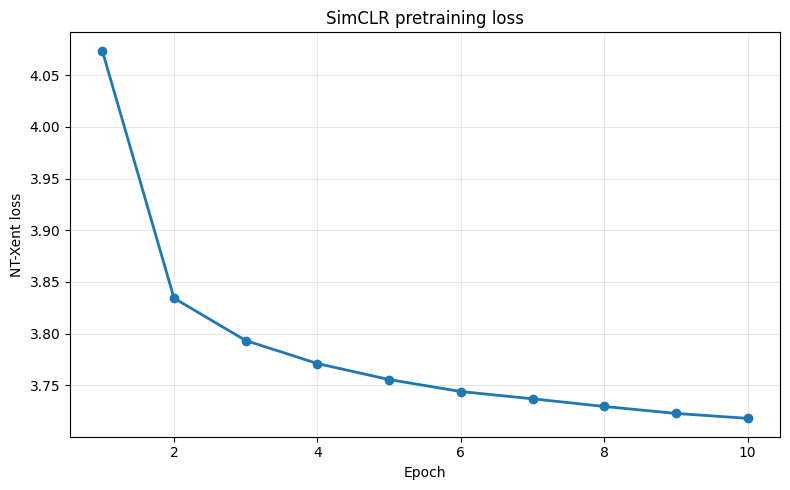

Saved: /Users/sherry/Desktop/Tomato_Disease/RESULTS_2.0/simclr/simclr_checkpoint.pth


In [10]:
SIMCLR_CKPT = f"{RESULTS_DIR}/simclr/simclr_checkpoint.pth"

if os.path.exists(SIMCLR_CKPT):
    print(f"SimCLR checkpoint already exists at:\n  {SIMCLR_CKPT}")
    print("Skipping pretraining (delete the file to force a retrain).")
    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    print(f"Loaded checkpoint (final loss = {simclr_ckpt['final_loss']:.4f}).")
else:
    set_seed(SIMCLR_SEED)
    ssl_dataset = SimCLRDataset(TOMATO_PATH, simclr_transform)
    ssl_loader  = DataLoader(ssl_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    print(f"SSL dataset: {len(ssl_dataset)} images, {len(ssl_loader)} batches/epoch")
    simclr_model = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=LR_SIMCLR)
    print("=" * 64)
    print(f"SimCLR fine-tune from ImageNet: {SIMCLR_EPOCHS} epochs (seed={SIMCLR_SEED})")
    print(f"Batch: {BATCH_SIZE}  LR: {LR_SIMCLR}  Temp: {SIMCLR_TEMP}")
    print("=" * 64)
    simclr_ft_history = {"epoch": [], "loss": [], "time_min": []}
    overall_start = time.time()
    for epoch in range(SIMCLR_EPOCHS):
        simclr_model.train()
        epoch_start = time.time()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(ssl_loader, desc=f"SimCLR {epoch+1}/{SIMCLR_EPOCHS}")
        for xi, xj in pbar:
            xi = xi.to(device, non_blocking=True)
            xj = xj.to(device, non_blocking=True)
            _, zi = simclr_model(xi)
            _, zj = simclr_model(xj)
            loss = nt_xent_loss(zi, zj, temperature=SIMCLR_TEMP)
            simclr_optimizer.zero_grad(); loss.backward(); simclr_optimizer.step()
            total_loss += loss.item(); n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_loss = total_loss / n_batches
        epoch_min = (time.time() - epoch_start) / 60
        simclr_ft_history["epoch"].append(epoch + 1)
        simclr_ft_history["loss"].append(avg_loss)
        simclr_ft_history["time_min"].append(epoch_min)
        print(f"  Epoch {epoch+1}/{SIMCLR_EPOCHS}  loss={avg_loss:.4f}  time={epoch_min:.1f}min")
    total_min = (time.time() - overall_start) / 60
    print(f"\nSimCLR pretraining complete. Total time: {total_min:.1f} min")
    torch.save({
        "model_state_dict": simclr_model.state_dict(),
        "encoder_state_dict": simclr_model.encoder.state_dict(),
        "projector_state_dict": simclr_model.projector.state_dict(),
        "epoch": SIMCLR_EPOCHS, "final_loss": simclr_ft_history["loss"][-1],
        "config": {"init": "imagenet", "epochs": SIMCLR_EPOCHS,
                   "batch_size": BATCH_SIZE, "lr": LR_SIMCLR,
                   "temperature": SIMCLR_TEMP, "feature_dim": 128,
                   "seed": SIMCLR_SEED},
    }, SIMCLR_CKPT)
    with open(f"{RESULTS_DIR}/simclr/simclr_history.json", "w") as f:
        json.dump(simclr_ft_history, f, indent=2)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(simclr_ft_history["epoch"], simclr_ft_history["loss"],
            marker="o", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("NT-Xent loss")
    ax.set_title("SimCLR pretraining loss")
    ax.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/simclr/simclr_loss_curve.png", dpi=150)
    plt.show()
    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    del simclr_model, simclr_optimizer
    empty_cache()
    print(f"Saved: {SIMCLR_CKPT}")

## Section 10 — Configure label % and define per-seed helpers

Two responsibilities:
1. Set `LABEL_PCT` for the current experiment (the only knob you change between runs).
2. Define `build_split_and_loaders(seed)` — rebuilds the 3-way split (labeled / unlabeled / val)
   plus the four loaders for a given seed. Each method's seed loop calls this once per seed so
   that all four methods at a given seed share the same data partition (a fair comparison).

Also defines `aggregate_seeds(...)` — combines per-seed metrics into `mean ± std`.

In [26]:
# ============================================================
# CHANGE THIS to 0.01, 0.20, or 0.40 between experiments
# ============================================================
LABEL_PCT = 0.40
# ============================================================

pct_tag = f"{int(LABEL_PCT*100)}pct"
CUR_OUT = f"{RESULTS_DIR}/{pct_tag}"
print(f"Active experiment: LABEL_PCT={LABEL_PCT}  (tag: {pct_tag})")
print(f"Seeds: {SEEDS}")
print(f"Output base: {CUR_OUT}")


def build_split_and_loaders(seed):
    """Build a fresh 3-way split + 4 loaders + clean_train_loader for the given seed.
    Returns a dict so the method cells can grab what they need."""
    set_seed(seed)
    labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
        base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
        min_per_class=10, seed=seed,
    )
    # Sanity checks
    assert len(set(labeled_idx)   & set(val_idx))       == 0
    assert len(set(labeled_idx)   & set(unlabeled_idx)) == 0
    assert len(set(unlabeled_idx) & set(val_idx))       == 0

    # Persist the split for reproducibility
    with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{seed}.json", "w") as f:
        json.dump({
            "seed": seed, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
            "min_per_class": 10,
            "labeled_idx": labeled_idx, "unlabeled_idx": unlabeled_idx,
            "val_idx": val_idx,
            "classes": base_dataset.classes,
        }, f)

    labeled_ds       = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
    unlabeled_ds     = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
    val_ds           = LabeledSubset(base_dataset, val_idx,       eval_transform)
    clean_train_ds   = LabeledSubset(base_dataset, labeled_idx,   eval_transform)

    return {
        "labeled_loader":    DataLoader(labeled_ds, batch_size=BATCH_SIZE, shuffle=True,
                                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True),
        "unlabeled_loader":  DataLoader(unlabeled_ds, batch_size=BATCH_SIZE, shuffle=True,
                                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True),
        "val_loader":        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                         num_workers=NUM_WORKERS, pin_memory=True),
        "train_loader":      DataLoader(labeled_ds, batch_size=BATCH_SIZE, shuffle=True,
                                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=False),
        "clean_train_loader": DataLoader(clean_train_ds, batch_size=BATCH_SIZE, shuffle=False,
                                          num_workers=NUM_WORKERS, pin_memory=True),
        "split_sizes": {"labeled": len(labeled_idx), "unlabeled": len(unlabeled_idx),
                        "val": len(val_idx)},
    }


@torch.no_grad()
def eval_clean_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total


def aggregate_seeds(per_seed_metrics, method_name, out_dir):
    """Compute mean ± std across seeds and save aggregate.json. Returns the aggregate."""
    overall_keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro",
                    "precision_weighted", "recall_weighted", "f1_weighted"]
    overall_agg = {}
    for k in overall_keys:
        vals = [m["overall"][k] for m in per_seed_metrics]
        overall_agg[k] = {"mean": float(np.mean(vals)), "std": float(np.std(vals)),
                          "values_by_seed": [float(v) for v in vals]}

    per_class_keys = ["accuracy", "precision", "recall", "f1"]
    per_class_agg = {"class_names": per_seed_metrics[0]["per_class"]["class_names"]}
    for k in per_class_keys:
        arr = np.array([m["per_class"][k] for m in per_seed_metrics])  # [n_seeds, n_classes]
        per_class_agg[k] = {
            "mean": arr.mean(axis=0).tolist(),
            "std":  arr.std(axis=0).tolist(),
        }

    gaps = []
    val_finals = []
    train_finals = []
    best_val_epochs = []
    for m in per_seed_metrics:
        ft = m.get("final_train_acc"); fv = m.get("final_val_acc")
        if ft is not None and fv is not None:
            gaps.append(ft - fv); train_finals.append(ft); val_finals.append(fv)
        h = m.get("history", {})
        if h.get("val_acc"):
            best_val_epochs.append(int(np.argmax(h["val_acc"]) + 1))

    aggregate = {
        "method": method_name,
        "n_seeds": len(per_seed_metrics),
        "seeds":   [m["seed"] for m in per_seed_metrics],
        "overall": overall_agg,
        "per_class": per_class_agg,
        "diagnostics": {
            "final_train_acc": {"mean": float(np.mean(train_finals)) if train_finals else None,
                                 "std":  float(np.std(train_finals))  if train_finals else None,
                                 "values_by_seed": train_finals},
            "final_val_acc":   {"mean": float(np.mean(val_finals))   if val_finals else None,
                                 "std":  float(np.std(val_finals))    if val_finals else None,
                                 "values_by_seed": val_finals},
            "final_gap":       {"mean": float(np.mean(gaps))         if gaps else None,
                                 "std":  float(np.std(gaps))          if gaps else None,
                                 "values_by_seed": gaps},
            "best_val_epoch":  {"values_by_seed": best_val_epochs},
        },
    }
    with open(f"{out_dir}/aggregate.json", "w") as f:
        json.dump(aggregate, f, indent=2)
    return aggregate


def print_aggregate(agg, method_name):
    o = agg["overall"]
    d = agg["diagnostics"]
    print(f"\n{method_name} aggregate over {agg['n_seeds']} seeds:")
    print(f"  Val accuracy:         {o['accuracy']['mean']*100:6.2f}% ± {o['accuracy']['std']*100:.2f}%")
    print(f"  Macro F1:             {o['f1_macro']['mean']*100:6.2f}% ± {o['f1_macro']['std']*100:.2f}%")
    print(f"  Weighted F1:          {o['f1_weighted']['mean']*100:6.2f}% ± {o['f1_weighted']['std']*100:.2f}%")
    if d["final_gap"]["mean"] is not None:
        print(f"  Final train-val gap:  {d['final_gap']['mean']:+6.2f}% ± {d['final_gap']['std']:.2f}%")
    print(f"  Best val epoch (per seed): {d['best_val_epoch']['values_by_seed']}")


results_cur = {}
print("Helpers defined. Run sections 11-14 next.")

Active experiment: LABEL_PCT=0.4  (tag: 40pct)
Seeds: [42, 123, 456]
Output base: /Users/sherry/Desktop/Tomato_Disease/RESULTS_2.0/40pct
Helpers defined. Run sections 11-14 next.


## Section 11 — B1: Supervised (multi-seed)

Loops over `SEEDS`. For each seed: build split + loaders → train with early stopping on
val → evaluate the best-val state on the **val set** → save to `seed_<N>/`. Aggregates
at the end into `B1_supervised/aggregate.json`.

In [28]:
# ===== B1: Supervised (ImageNet init) — multi-seed =====
method_name = "B1_supervised"
method_out  = f"{CUR_OUT}/{method_name}"
b1_per_seed = []

for SEED_CUR in SEEDS:
    print("\n" + "=" * 72)
    print(f"B1 @ {pct_tag} | seed={SEED_CUR}")
    print("=" * 72)

    loaders = build_split_and_loaders(SEED_CUR)
    sizes = loaders["split_sizes"]
    total_n = sum(sizes.values())
    print(f"Split sizes — labeled: {sizes['labeled']} ({100*sizes['labeled']/total_n:.1f}%) | "
          f"unlabeled: {sizes['unlabeled']} ({100*sizes['unlabeled']/total_n:.1f}%) | "
          f"val: {sizes['val']} ({100*sizes['val']/total_n:.1f}%)")

    set_seed(SEED_CUR)   # re-seed for model init reproducibility
    sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    sup_model.fc = nn.Linear(512, NUM_CLASSES)
    sup_model = sup_model.to(device)

    optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
    criterion = nn.CrossEntropyLoss()
    EPOCHS = EPOCHS_DEFAULT

    b1_history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": []}
    best_val, best_state = 0.0, None
    start = time.time()

    for epoch in range(EPOCHS):
        sup_model.train()
        tl, nb = 0.0, 0
        for imgs, labels in loaders["train_loader"]:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(sup_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1

        train_acc = eval_clean_accuracy(sup_model, loaders["clean_train_loader"])
        val_acc   = eval_clean_accuracy(sup_model, loaders["val_loader"])

        b1_history["epoch"].append(epoch + 1)
        b1_history["train_loss"].append(tl / nb)
        b1_history["train_acc"].append(train_acc)
        b1_history["val_acc"].append(val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(sup_model.state_dict())
        gap = train_acc - val_acc
        print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.4f}  "
              f"train={train_acc:6.2f}%  val={val_acc:6.2f}%  gap={gap:+6.2f}%  "
              f"(best val: {best_val:.2f}%)")

    print(f"  Seed {SEED_CUR} done in {(time.time()-start)/60:.1f}m  (best val: {best_val:.2f}%)")
    sup_model.load_state_dict(best_state)
    metrics = full_evaluation(
        model=sup_model, loader=loaders["val_loader"],
        class_names=base_dataset.classes, method_name=method_name,
        history=b1_history,
        out_dir=f"{method_out}/seed_{SEED_CUR}",
        pct_tag=pct_tag, seed=SEED_CUR,
    )
    b1_per_seed.append(metrics)
    del sup_model, optimizer, loaders
    empty_cache()

# Aggregate
b1_agg = aggregate_seeds(b1_per_seed, method_name, method_out)
print_aggregate(b1_agg, method_name)
results_cur[method_name] = b1_agg


B1 @ 40pct | seed=42
Split sizes — labeled: 6400 (40.0%) | unlabeled: 8014 (50.1%) | val: 1597 (10.0%)
  Ep  1/30  loss=0.3454  train= 87.67%  val= 85.66%  gap= +2.01%  (best val: 85.66%)
  Ep  2/30  loss=0.1153  train= 93.80%  val= 92.80%  gap= +1.00%  (best val: 92.80%)
  Ep  3/30  loss=0.0974  train= 90.55%  val= 88.60%  gap= +1.94%  (best val: 92.80%)


KeyboardInterrupt: 

## Section 12 — B3: Self-supervised (multi-seed)

In [ ]:
# ===== B3: Self-supervised (SimCLR + Full Fine-tune) — multi-seed =====
class SimCLRFineTune(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


method_name = "B3_self_supervised"
method_out  = f"{CUR_OUT}/{method_name}"
b3_per_seed = []

for SEED_CUR in SEEDS:
    print("\n" + "=" * 72)
    print(f"B3 @ {pct_tag} | seed={SEED_CUR}  (SimCLR + Full FT, LR={LR_FT})")
    print("=" * 72)

    loaders = build_split_and_loaders(SEED_CUR)
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)

    # Sanity: all params trainable
    trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in ft_model.parameters())
    assert trainable == total_p, "Some params frozen in B3 — investigate"

    optimizer = torch.optim.Adam(ft_model.parameters(), lr=LR_FT)
    criterion = nn.CrossEntropyLoss()
    EPOCHS = EPOCHS_DEFAULT

    b3_history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": []}
    best_val, best_state = 0.0, None
    start = time.time()

    for epoch in range(EPOCHS):
        ft_model.train()
        tl, nb = 0.0, 0
        for imgs, labels in loaders["train_loader"]:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(ft_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1

        train_acc = eval_clean_accuracy(ft_model, loaders["clean_train_loader"])
        val_acc   = eval_clean_accuracy(ft_model, loaders["val_loader"])

        b3_history["epoch"].append(epoch + 1)
        b3_history["train_loss"].append(tl / nb)
        b3_history["train_acc"].append(train_acc)
        b3_history["val_acc"].append(val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(ft_model.state_dict())
        gap = train_acc - val_acc
        print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.3f}  "
              f"train={train_acc:6.2f}%  val={val_acc:6.2f}%  gap={gap:+6.2f}%  "
              f"(best val: {best_val:.2f}%)")

    print(f"  Seed {SEED_CUR} done in {(time.time()-start)/60:.1f}m  (best val: {best_val:.2f}%)")
    ft_model.load_state_dict(best_state)
    metrics = full_evaluation(
        model=ft_model, loader=loaders["val_loader"],
        class_names=base_dataset.classes, method_name=method_name,
        history=b3_history,
        out_dir=f"{method_out}/seed_{SEED_CUR}",
        pct_tag=pct_tag, seed=SEED_CUR,
    )
    b3_per_seed.append(metrics)
    del ft_model, optimizer, simclr_clean, loaders
    empty_cache()

b3_agg = aggregate_seeds(b3_per_seed, method_name, method_out)
print_aggregate(b3_agg, method_name)
results_cur[method_name] = b3_agg


B3 @ 1pct | seed=42  (SimCLR + Full FT, LR=0.0001)


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  loss=2.012  train= 50.61%  val= 49.66%  gap= +0.95%  (best val: 49.66%)
  Ep  2/30  loss=1.570  train= 68.29%  val= 62.74%  gap= +5.55%  (best val: 62.74%)
  Ep  3/30  loss=1.308  train= 76.22%  val= 66.69%  gap= +9.53%  (best val: 66.69%)
  Ep  4/30  loss=0.990  train= 79.88%  val= 69.32%  gap=+10.56%  (best val: 69.32%)
  Ep  5/30  loss=0.831  train= 84.15%  val= 71.70%  gap=+12.45%  (best val: 71.70%)
  Ep  6/30  loss=0.694  train= 86.59%  val= 74.14%  gap=+12.45%  (best val: 74.14%)
  Ep  7/30  loss=0.677  train= 92.07%  val= 76.21%  gap=+15.87%  (best val: 76.21%)
  Ep  8/30  loss=0.558  train= 95.12%  val= 77.58%  gap=+17.54%  (best val: 77.58%)
  Ep  9/30  loss=0.437  train= 95.12%  val= 78.52%  gap=+16.60%  (best val: 78.52%)
  Ep 10/30  loss=0.393  train= 95.12%  val= 79.71%  gap=+15.41%  (best val: 79.71%)
  Ep 11/30  loss=0.329  train= 96.95%  val= 80.84%  gap=+16.11%  (best val: 80.84%)
  Ep 12/30  loss=0.276  train= 97.56%  val= 81.65%  gap=+15.91%  (best val: 

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  loss=2.571  train= 29.27%  val= 21.42%  gap= +7.85%  (best val: 21.42%)
  Ep  2/30  loss=2.027  train= 51.22%  val= 41.77%  gap= +9.45%  (best val: 41.77%)
  Ep  3/30  loss=1.649  train= 62.20%  val= 50.22%  gap=+11.98%  (best val: 50.22%)
  Ep  4/30  loss=1.344  train= 68.90%  val= 56.61%  gap=+12.30%  (best val: 56.61%)
  Ep  5/30  loss=1.102  train= 76.83%  val= 61.93%  gap=+14.90%  (best val: 61.93%)
  Ep  6/30  loss=0.918  train= 81.71%  val= 66.31%  gap=+15.40%  (best val: 66.31%)
  Ep  7/30  loss=0.747  train= 82.32%  val= 69.76%  gap=+12.56%  (best val: 69.76%)
  Ep  8/30  loss=0.633  train= 85.98%  val= 72.01%  gap=+13.97%  (best val: 72.01%)
  Ep  9/30  loss=0.594  train= 87.80%  val= 73.76%  gap=+14.04%  (best val: 73.76%)
  Ep 10/30  loss=0.471  train= 89.02%  val= 74.83%  gap=+14.20%  (best val: 74.83%)
  Ep 11/30  loss=0.404  train= 91.46%  val= 76.27%  gap=+15.20%  (best val: 76.27%)
  Ep 12/30  loss=0.306  train= 92.07%  val= 77.77%  gap=+14.30%  (best val: 

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  loss=2.312  train= 26.83%  val= 22.73%  gap= +4.10%  (best val: 22.73%)
  Ep  2/30  loss=1.774  train= 53.66%  val= 40.70%  gap=+12.96%  (best val: 40.70%)
  Ep  3/30  loss=1.419  train= 65.85%  val= 54.73%  gap=+11.13%  (best val: 54.73%)
  Ep  4/30  loss=1.190  train= 76.83%  val= 62.62%  gap=+14.21%  (best val: 62.62%)
  Ep  5/30  loss=0.999  train= 79.88%  val= 66.81%  gap=+13.07%  (best val: 66.81%)
  Ep  6/30  loss=0.831  train= 83.54%  val= 69.13%  gap=+14.41%  (best val: 69.13%)
  Ep  7/30  loss=0.695  train= 85.37%  val= 70.76%  gap=+14.61%  (best val: 70.76%)
  Ep  8/30  loss=0.598  train= 87.20%  val= 72.14%  gap=+15.06%  (best val: 72.14%)
  Ep  9/30  loss=0.500  train= 90.85%  val= 73.26%  gap=+17.59%  (best val: 73.26%)
  Ep 10/30  loss=0.434  train= 92.68%  val= 74.51%  gap=+18.17%  (best val: 74.51%)
  Ep 11/30  loss=0.361  train= 95.73%  val= 76.14%  gap=+19.59%  (best val: 76.14%)
  Ep 12/30  loss=0.280  train= 95.73%  val= 77.46%  gap=+18.27%  (best val: 

## Section 13 — B4: Semi-supervised (multi-seed)

In [ ]:
# ===== B4: Semi-supervised MixMatch (ImageNet init) — multi-seed =====
method_name = "B4_semi_supervised"
method_out  = f"{CUR_OUT}/{method_name}"
b4_per_seed = []

for SEED_CUR in SEEDS:
    print("\n" + "=" * 72)
    print(f"B4 @ {pct_tag} | seed={SEED_CUR}  (MixMatch, LR={LR_MM})")
    print("=" * 72)

    loaders = build_split_and_loaders(SEED_CUR)
    set_seed(SEED_CUR)
    mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    mm_model.fc = nn.Linear(512, NUM_CLASSES)
    mm_model = mm_model.to(device)

    optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_MM)
    EPOCHS_MM = EPOCHS_DEFAULT

    b4_history = {"epoch": [], "loss_x": [], "loss_u": [], "train_acc": [], "val_acc": []}
    best_val, best_state = 0.0, None
    start = time.time()

    for epoch in range(EPOCHS_MM):
        mm_model.train()
        tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(loaders["unlabeled_loader"])

        for bx, by in loaders["labeled_loader"]:
            try:
                buv = next(uiter)
            except StopIteration:
                uiter = iter(loaders["unlabeled_loader"]); buv = next(uiter)

            bx, by = bx.to(device), by.to(device)
            buv = [v.to(device) for v in buv]

            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv:
                    probs += F.softmax(mm_model(v), dim=1)
                probs /= len(buv)
                pseudo = sharpen(probs, T=SHARPEN_TEMP)

            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx] + buv, dim=0)
            at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

            n = bx.size(0)
            xp, yp = mx[:n], my[:n]
            up, uy = mx[n:], my[n:]

            lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1

        train_acc = eval_clean_accuracy(mm_model, loaders["clean_train_loader"])
        val_acc   = eval_clean_accuracy(mm_model, loaders["val_loader"])

        b4_history["epoch"].append(epoch + 1)
        b4_history["loss_x"].append(tlx / nb)
        b4_history["loss_u"].append(tlu / nb)
        b4_history["train_acc"].append(train_acc)
        b4_history["val_acc"].append(val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(mm_model.state_dict())
        gap = train_acc - val_acc
        print(f"  Ep {epoch+1:>2}/{EPOCHS_MM}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
              f"train={train_acc:6.2f}%  val={val_acc:6.2f}%  gap={gap:+6.2f}%  "
              f"(best val: {best_val:.2f}%)")

    print(f"  Seed {SEED_CUR} done in {(time.time()-start)/60:.1f}m  (best val: {best_val:.2f}%)")
    mm_model.load_state_dict(best_state)
    metrics = full_evaluation(
        model=mm_model, loader=loaders["val_loader"],
        class_names=base_dataset.classes, method_name=method_name,
        history=b4_history,
        out_dir=f"{method_out}/seed_{SEED_CUR}",
        pct_tag=pct_tag, seed=SEED_CUR,
    )
    b4_per_seed.append(metrics)
    del mm_model, optimizer, loaders
    empty_cache()

b4_agg = aggregate_seeds(b4_per_seed, method_name, method_out)
print_aggregate(b4_agg, method_name)
results_cur[method_name] = b4_agg


B4 @ 1pct | seed=42  (MixMatch, LR=0.0001)


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.308  lu=0.0108  train= 19.51%  val= 21.48%  gap= -1.97%  (best val: 21.48%)
  Ep  2/30  lx=2.111  lu=0.0042  train= 29.88%  val= 27.80%  gap= +2.08%  (best val: 27.80%)
  Ep  3/30  lx=1.855  lu=0.0054  train= 49.39%  val= 38.82%  gap=+10.57%  (best val: 38.82%)
  Ep  4/30  lx=1.674  lu=0.0052  train= 67.68%  val= 49.28%  gap=+18.40%  (best val: 49.28%)
  Ep  5/30  lx=1.885  lu=0.0102  train= 78.05%  val= 59.05%  gap=+19.00%  (best val: 59.05%)
  Ep  6/30  lx=1.697  lu=0.0078  train= 84.15%  val= 65.12%  gap=+19.02%  (best val: 65.12%)
  Ep  7/30  lx=1.746  lu=0.0091  train= 85.37%  val= 69.51%  gap=+15.86%  (best val: 69.51%)
  Ep  8/30  lx=1.163  lu=0.0051  train= 88.41%  val= 71.32%  gap=+17.09%  (best val: 71.32%)
  Ep  9/30  lx=1.642  lu=0.0115  train= 89.63%  val= 72.39%  gap=+17.25%  (best val: 72.39%)
  Ep 10/30  lx=1.230  lu=0.0059  train= 89.63%  val= 73.45%  gap=+16.18%  (best val: 73.45%)
  Ep 11/30  lx=0.732  lu=0.0062  train= 94.51%  val= 75.02%  gap=+19.5

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.459  lu=0.0064  train= 14.63%  val= 12.09%  gap= +2.55%  (best val: 12.09%)
  Ep  2/30  lx=2.216  lu=0.0054  train= 26.83%  val= 20.16%  gap= +6.67%  (best val: 20.16%)
  Ep  3/30  lx=2.088  lu=0.0065  train= 43.29%  val= 31.93%  gap=+11.36%  (best val: 31.93%)
  Ep  4/30  lx=2.019  lu=0.0094  train= 60.98%  val= 44.27%  gap=+16.71%  (best val: 44.27%)
  Ep  5/30  lx=1.761  lu=0.0059  train= 70.12%  val= 54.04%  gap=+16.08%  (best val: 54.04%)
  Ep  6/30  lx=1.363  lu=0.0055  train= 82.32%  val= 63.62%  gap=+18.70%  (best val: 63.62%)
  Ep  7/30  lx=1.643  lu=0.0078  train= 86.59%  val= 68.50%  gap=+18.08%  (best val: 68.50%)
  Ep  8/30  lx=1.801  lu=0.0117  train= 89.63%  val= 72.64%  gap=+17.00%  (best val: 72.64%)
  Ep  9/30  lx=1.758  lu=0.0129  train= 93.90%  val= 75.14%  gap=+18.76%  (best val: 75.14%)
  Ep 10/30  lx=1.344  lu=0.0075  train= 95.73%  val= 76.27%  gap=+19.46%  (best val: 76.27%)
  Ep 11/30  lx=1.530  lu=0.0099  train= 97.56%  val= 78.15%  gap=+19.4

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.404  lu=0.0074  train= 21.34%  val= 21.92%  gap= -0.57%  (best val: 21.92%)
  Ep  2/30  lx=2.268  lu=0.0087  train= 31.10%  val= 28.24%  gap= +2.86%  (best val: 28.24%)
  Ep  3/30  lx=2.129  lu=0.0090  train= 37.20%  val= 32.25%  gap= +4.95%  (best val: 32.25%)
  Ep  4/30  lx=1.890  lu=0.0042  train= 45.12%  val= 36.69%  gap= +8.43%  (best val: 36.69%)
  Ep  5/30  lx=1.958  lu=0.0081  train= 52.44%  val= 41.39%  gap=+11.05%  (best val: 41.39%)
  Ep  6/30  lx=1.851  lu=0.0077  train= 57.93%  val= 46.90%  gap=+11.03%  (best val: 46.90%)
  Ep  7/30  lx=1.289  lu=0.0066  train= 67.68%  val= 53.85%  gap=+13.83%  (best val: 53.85%)
  Ep  8/30  lx=1.515  lu=0.0064  train= 76.83%  val= 59.80%  gap=+17.03%  (best val: 59.80%)
  Ep  9/30  lx=1.665  lu=0.0100  train= 83.54%  val= 64.31%  gap=+19.23%  (best val: 64.31%)
  Ep 10/30  lx=1.410  lu=0.0065  train= 89.02%  val= 69.07%  gap=+19.96%  (best val: 69.07%)
  Ep 11/30  lx=1.365  lu=0.0077  train= 90.85%  val= 72.20%  gap=+18.6

## Section 14 — B5 (full): Hybrid (multi-seed)

In [ ]:
# ===== B5 (full): Hybrid — SimCLR + MixMatch full FT — multi-seed =====
class SimCLRMixMatchFull(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


method_name = "B5_hybrid"
method_out  = f"{CUR_OUT}/{method_name}"
b5_per_seed = []

for SEED_CUR in SEEDS:
    print("\n" + "=" * 72)
    print(f"B5 (full) @ {pct_tag} | seed={SEED_CUR}  (SimCLR + MixMatch full FT, LR={LR_HYBRID})")
    print("=" * 72)

    loaders = build_split_and_loaders(SEED_CUR)
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    b5_full = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)

    trainable = sum(p.numel() for p in b5_full.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in b5_full.parameters())
    assert trainable == total_p, "Some params frozen in B5 — investigate"

    optimizer = torch.optim.Adam(b5_full.parameters(), lr=LR_HYBRID)
    EPOCHS = EPOCHS_DEFAULT

    b5_history = {"epoch": [], "loss_x": [], "loss_u": [], "train_acc": [], "val_acc": []}
    best_val, best_state = 0.0, None
    start = time.time()

    for epoch in range(EPOCHS):
        b5_full.train()
        tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(loaders["unlabeled_loader"])

        for bx, by in loaders["labeled_loader"]:
            try:
                buv = next(uiter)
            except StopIteration:
                uiter = iter(loaders["unlabeled_loader"]); buv = next(uiter)

            bx, by = bx.to(device), by.to(device)
            buv = [v.to(device) for v in buv]

            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv:
                    probs += F.softmax(b5_full(v), dim=1)
                probs /= len(buv)
                pseudo = sharpen(probs, T=SHARPEN_TEMP)

            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx] + buv, dim=0)
            at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

            n = bx.size(0)
            xp, yp = mx[:n], my[:n]
            up, uy = mx[n:], my[n:]

            lx = -torch.mean(torch.sum(yp * F.log_softmax(b5_full(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(b5_full(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1

        train_acc = eval_clean_accuracy(b5_full, loaders["clean_train_loader"])
        val_acc   = eval_clean_accuracy(b5_full, loaders["val_loader"])

        b5_history["epoch"].append(epoch + 1)
        b5_history["loss_x"].append(tlx / nb)
        b5_history["loss_u"].append(tlu / nb)
        b5_history["train_acc"].append(train_acc)
        b5_history["val_acc"].append(val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(b5_full.state_dict())
        gap = train_acc - val_acc
        print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
              f"train={train_acc:6.2f}%  val={val_acc:6.2f}%  gap={gap:+6.2f}%  "
              f"(best val: {best_val:.2f}%)")

    print(f"  Seed {SEED_CUR} done in {(time.time()-start)/60:.1f}m  (best val: {best_val:.2f}%)")
    b5_full.load_state_dict(best_state)
    metrics = full_evaluation(
        model=b5_full, loader=loaders["val_loader"],
        class_names=base_dataset.classes, method_name=method_name,
        history=b5_history,
        out_dir=f"{method_out}/seed_{SEED_CUR}",
        pct_tag=pct_tag, seed=SEED_CUR,
    )
    b5_per_seed.append(metrics)
    del b5_full, optimizer, simclr_clean, loaders
    empty_cache()

b5_agg = aggregate_seeds(b5_per_seed, method_name, method_out)
print_aggregate(b5_agg, method_name)
results_cur[method_name] = b5_agg

# Save the per-pct summary
with open(f"{CUR_OUT}/pct_summary.json", "w") as f:
    json.dump({m: a for m, a in results_cur.items()}, f, indent=2)
print("\n" + "=" * 72)
print(f"All four methods @ {pct_tag} complete. Aggregate saved to {CUR_OUT}/pct_summary.json")
print("=" * 72)


B5 (full) @ 1pct | seed=42  (SimCLR + MixMatch full FT, LR=0.0001)


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.163  lu=0.0120  train= 35.98%  val= 38.95%  gap= -2.97%  (best val: 38.95%)
  Ep  2/30  lx=1.944  lu=0.0051  train= 49.39%  val= 47.78%  gap= +1.61%  (best val: 47.78%)
  Ep  3/30  lx=1.705  lu=0.0058  train= 62.80%  val= 57.67%  gap= +5.13%  (best val: 57.67%)
  Ep  4/30  lx=1.628  lu=0.0048  train= 67.68%  val= 64.81%  gap= +2.87%  (best val: 64.81%)
  Ep  5/30  lx=1.893  lu=0.0118  train= 72.56%  val= 67.88%  gap= +4.68%  (best val: 67.88%)
  Ep  6/30  lx=1.659  lu=0.0079  train= 76.83%  val= 69.13%  gap= +7.70%  (best val: 69.13%)
  Ep  7/30  lx=1.684  lu=0.0090  train= 80.49%  val= 71.57%  gap= +8.92%  (best val: 71.57%)
  Ep  8/30  lx=1.164  lu=0.0054  train= 81.10%  val= 72.70%  gap= +8.40%  (best val: 72.70%)
  Ep  9/30  lx=1.672  lu=0.0129  train= 81.71%  val= 73.51%  gap= +8.19%  (best val: 73.51%)
  Ep 10/30  lx=1.291  lu=0.0060  train= 84.15%  val= 74.39%  gap= +9.76%  (best val: 74.39%)
  Ep 11/30  lx=0.875  lu=0.0061  train= 84.76%  val= 75.27%  gap= +9.4

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.585  lu=0.0039  train= 14.02%  val= 12.34%  gap= +1.69%  (best val: 12.34%)
  Ep  2/30  lx=2.361  lu=0.0040  train= 31.71%  val= 23.92%  gap= +7.79%  (best val: 23.92%)
  Ep  3/30  lx=2.186  lu=0.0054  train= 43.29%  val= 32.44%  gap=+10.86%  (best val: 32.44%)
  Ep  4/30  lx=2.028  lu=0.0081  train= 53.05%  val= 40.83%  gap=+12.22%  (best val: 40.83%)
  Ep  5/30  lx=1.784  lu=0.0051  train= 58.54%  val= 47.46%  gap=+11.07%  (best val: 47.46%)
  Ep  6/30  lx=1.566  lu=0.0046  train= 66.46%  val= 51.60%  gap=+14.87%  (best val: 51.60%)
  Ep  7/30  lx=1.719  lu=0.0063  train= 70.73%  val= 55.67%  gap=+15.06%  (best val: 55.67%)
  Ep  8/30  lx=1.742  lu=0.0127  train= 72.56%  val= 59.11%  gap=+13.45%  (best val: 59.11%)
  Ep  9/30  lx=1.846  lu=0.0125  train= 75.00%  val= 61.37%  gap=+13.63%  (best val: 61.37%)
  Ep 10/30  lx=1.455  lu=0.0055  train= 78.05%  val= 63.62%  gap=+14.43%  (best val: 63.62%)
  Ep 11/30  lx=1.660  lu=0.0097  train= 78.66%  val= 65.75%  gap=+12.9

/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.304  lu=0.0084  train= 18.29%  val= 16.59%  gap= +1.70%  (best val: 16.59%)
  Ep  2/30  lx=2.139  lu=0.0106  train= 23.17%  val= 21.23%  gap= +1.94%  (best val: 21.23%)
  Ep  3/30  lx=2.064  lu=0.0094  train= 34.15%  val= 27.93%  gap= +6.22%  (best val: 27.93%)
  Ep  4/30  lx=1.856  lu=0.0044  train= 43.90%  val= 35.32%  gap= +8.59%  (best val: 35.32%)
  Ep  5/30  lx=1.838  lu=0.0078  train= 56.10%  val= 44.96%  gap=+11.14%  (best val: 44.96%)
  Ep  6/30  lx=1.823  lu=0.0066  train= 64.02%  val= 52.85%  gap=+11.18%  (best val: 52.85%)
  Ep  7/30  lx=1.321  lu=0.0060  train= 71.34%  val= 60.18%  gap=+11.17%  (best val: 60.18%)
  Ep  8/30  lx=1.556  lu=0.0051  train= 76.83%  val= 64.75%  gap=+12.08%  (best val: 64.75%)
  Ep  9/30  lx=1.625  lu=0.0093  train= 79.88%  val= 67.31%  gap=+12.56%  (best val: 67.31%)
  Ep 10/30  lx=1.516  lu=0.0064  train= 83.54%  val= 69.82%  gap=+13.72%  (best val: 69.82%)
  Ep 11/30  lx=1.432  lu=0.0070  train= 87.20%  val= 71.51%  gap=+15.6

## Section 15 — Overfitting diagnostic (across seeds)

Same five-verdict scheme as v3, applied to **mean train/val curves across seeds**.
Saves a 2×2 plot with the spread shaded (mean ± std).

OVERFITTING DIAGNOSTIC @ 1pct (across 3 seeds)
Method                   train(mean)     val(mean)      gap    trend  verdict
----------------------------------------------------------------------------------------------------
B1_supervised                 77.64%        60.11%  +17.53%   +4.04%  Overfitting (large gap)
B3_self_supervised           100.00%        85.89%  +14.11%   +1.80%  Mild gap, acceptable
B4_semi_supervised           100.00%        86.29%  +13.71%   +1.44%  Mild gap, acceptable
B5_hybrid                     98.78%        83.24%  +15.54%   +5.26%  Overfitting (large gap)


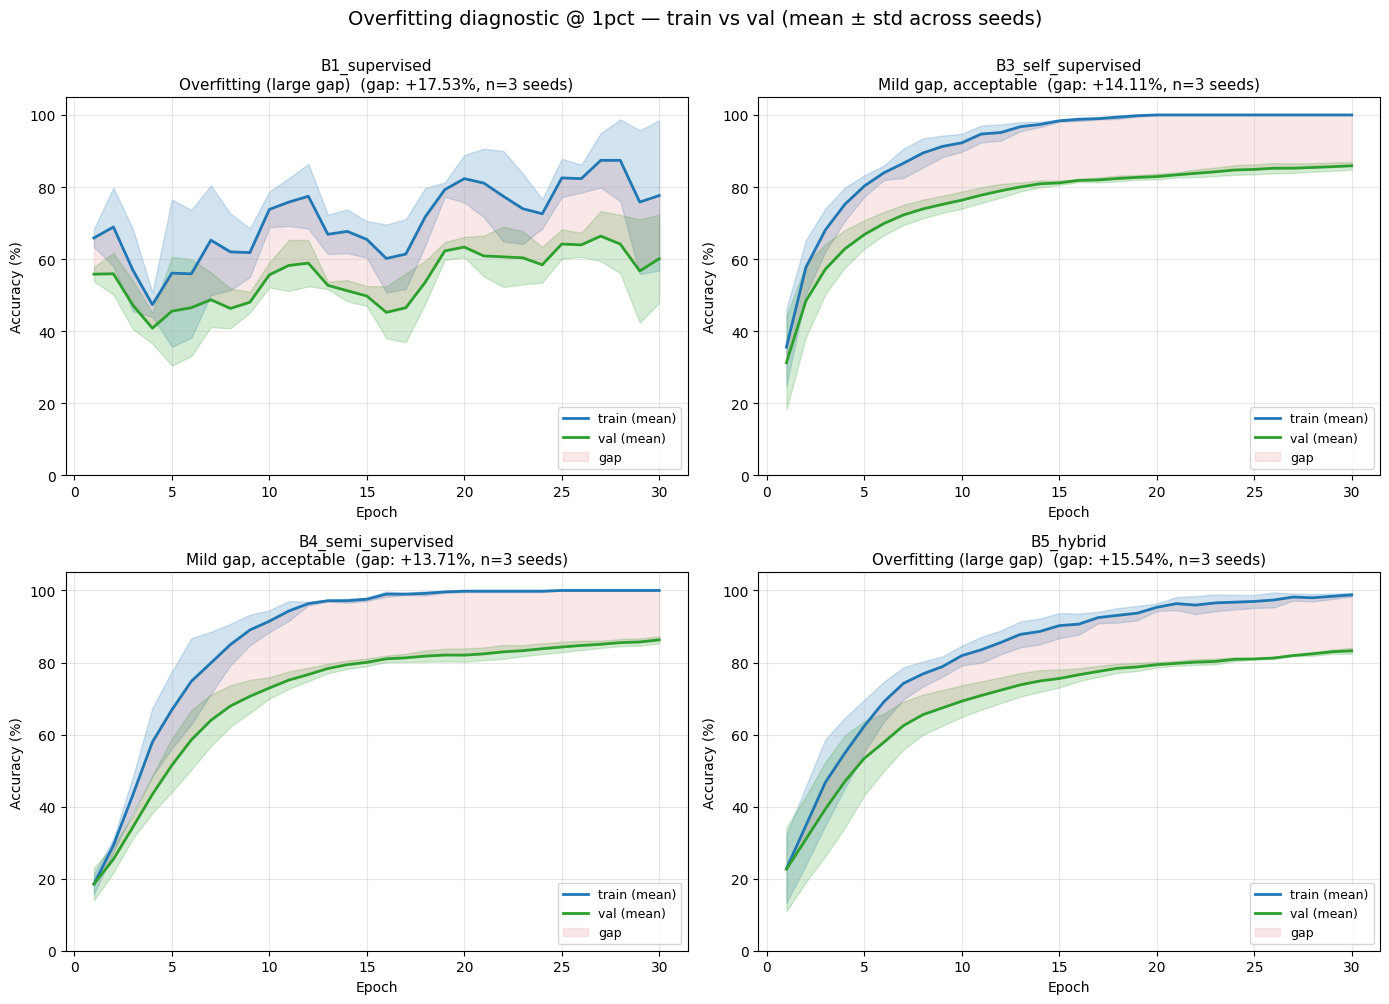


Diagnostic saved to: /Users/sherry/Desktop/Tomato_Disease/RESULTS_2.0/1pct/overfitting/


In [ ]:
# ===== Overfitting diagnostic — uses mean across seeds =====
OVERFIT_OUT = f"{CUR_OUT}/overfitting"
os.makedirs(OVERFIT_OUT, exist_ok=True)


def diagnose_from_aggregate(method_out):
    """Read all seed metrics in `method_out`, return (verdict, evidence, mean_train, mean_val)."""
    seed_dirs = sorted([d for d in os.listdir(method_out)
                         if d.startswith("seed_") and
                         os.path.isdir(os.path.join(method_out, d))])
    if not seed_dirs:
        return "no data", {}, None, None

    train_curves, val_curves = [], []
    for sd in seed_dirs:
        p = f"{method_out}/{sd}/metrics.json"
        if not os.path.exists(p): continue
        with open(p) as f: m = json.load(f)
        h = m.get("history", {})
        if "train_acc" in h and "val_acc" in h:
            train_curves.append(h["train_acc"])
            val_curves.append(h["val_acc"])

    if not train_curves:
        return "no train_acc tracked", {}, None, None

    min_len = min(len(c) for c in train_curves)
    train_curves = np.array([c[:min_len] for c in train_curves])
    val_curves   = np.array([c[:min_len] for c in val_curves])

    mean_train = train_curves.mean(axis=0)
    mean_val   = val_curves.mean(axis=0)
    std_train  = train_curves.std(axis=0)
    std_val    = val_curves.std(axis=0)

    gaps = mean_train - mean_val
    final_gap = float(gaps[-1])
    final_val = float(mean_val[-1])
    n = len(gaps)
    first_half_mean  = float(np.mean(gaps[:n//2])) if n >= 2 else final_gap
    second_half_mean = float(np.mean(gaps[n//2:])) if n >= 2 else final_gap
    gap_trend = second_half_mean - first_half_mean

    evidence = {
        "mean_final_train_acc": float(mean_train[-1]),
        "mean_final_val_acc":   float(mean_val[-1]),
        "mean_final_gap":       float(final_gap),
        "gap_trend_second_minus_first_half": float(gap_trend),
        "n_seeds_used": int(len(train_curves)),
    }

    if final_gap < 2 and final_val > 95:
        verdict = "Suspicious — check leakage"
    elif final_gap > 15:
        verdict = "Overfitting (large gap)"
    elif gap_trend > 5:
        verdict = "Overfitting (growing gap)"
    elif final_gap > 5:
        verdict = "Mild gap, acceptable"
    else:
        verdict = "Healthy"
    return verdict, evidence, (mean_train, std_train), (mean_val, std_val)


methods = ["B1_supervised", "B3_self_supervised",
           "B4_semi_supervised", "B5_hybrid"]
diagnostic = {}

print("=" * 100)
print(f"OVERFITTING DIAGNOSTIC @ {pct_tag} (across {len(SEEDS)} seeds)")
print("=" * 100)
print(f"{'Method':<22} {'train(mean)':>13} {'val(mean)':>13} {'gap':>8} {'trend':>8}  verdict")
print("-" * 100)

curves_for_plot = {}
for method in methods:
    p = f"{CUR_OUT}/{method}"
    verdict, evid, train_curve, val_curve = diagnose_from_aggregate(p)
    diagnostic[method] = {"verdict": verdict, **evid}
    if train_curve is not None:
        curves_for_plot[method] = (train_curve, val_curve)
        print(f"{method:<22} {evid['mean_final_train_acc']:>12.2f}% "
              f"{evid['mean_final_val_acc']:>12.2f}% "
              f"{evid['mean_final_gap']:>+7.2f}% "
              f"{evid['gap_trend_second_minus_first_half']:>+7.2f}%  {verdict}")
    else:
        print(f"{method:<22} {verdict}")

print("=" * 100)
with open(f"{OVERFIT_OUT}/diagnostic.json", "w") as f:
    json.dump(diagnostic, f, indent=2)

# ---- 2x2 plot with std shading ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, method in zip(axes.flat, methods):
    if method not in curves_for_plot:
        ax.text(0.5, 0.5, f"(no data for {method})",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method); ax.set_axis_off()
        continue
    (mean_train, std_train), (mean_val, std_val) = curves_for_plot[method]
    ep = np.arange(1, len(mean_train) + 1)
    ax.plot(ep, mean_train, color="tab:blue", label="train (mean)", linewidth=2)
    ax.fill_between(ep, mean_train - std_train, mean_train + std_train,
                    alpha=0.2, color="tab:blue")
    ax.plot(ep, mean_val, color="tab:green", label="val (mean)", linewidth=2)
    ax.fill_between(ep, mean_val - std_val, mean_val + std_val,
                    alpha=0.2, color="tab:green")
    ax.fill_between(ep, mean_train, mean_val, alpha=0.10, color="tab:red", label="gap")

    info = diagnostic[method]
    ax.set_title(f"{method}\n{info['verdict']}  (gap: {info['mean_final_gap']:+.2f}%, "
                  f"n={info['n_seeds_used']} seeds)", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle(f"Overfitting diagnostic @ {pct_tag} — train vs val (mean ± std across seeds)",
              fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f"{OVERFIT_OUT}/train_vs_val_2x2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDiagnostic saved to: {OVERFIT_OUT}/")

## Section 16 — Per-pct summary table (with CIs)

Pretty-printed `mean ± std` table for the current `LABEL_PCT`.

In [ ]:
print("=" * 88)
print(f"SUMMARY @ {pct_tag}  (val set, mean ± std across {len(SEEDS)} seeds)")
print("=" * 88)
print(f"{'Method':<22}  {'Val Acc':<14}  {'Macro F1':<14}  {'Wtd F1':<14}  {'Gap':<12}")
print("-" * 88)
for method in ["B1_supervised", "B3_self_supervised",
               "B4_semi_supervised", "B5_hybrid"]:
    agg = results_cur.get(method)
    if agg is None:
        print(f"{method:<22}  (not yet run)")
        continue
    o = agg["overall"]; d = agg["diagnostics"]
    acc_str = f"{o['accuracy']['mean']*100:5.2f} ± {o['accuracy']['std']*100:4.2f}%"
    f1m_str = f"{o['f1_macro']['mean']*100:5.2f} ± {o['f1_macro']['std']*100:4.2f}%"
    f1w_str = f"{o['f1_weighted']['mean']*100:5.2f} ± {o['f1_weighted']['std']*100:4.2f}%"
    if d["final_gap"]["mean"] is not None:
        gap_str = f"{d['final_gap']['mean']:+5.2f} ± {d['final_gap']['std']:4.2f}%"
    else:
        gap_str = "n/a"
    print(f"{method:<22}  {acc_str:<14}  {f1m_str:<14}  {f1w_str:<14}  {gap_str:<12}")
print("=" * 88)

SUMMARY @ 1pct  (val set, mean ± std across 3 seeds)
Method                  Val Acc         Macro F1        Wtd F1          Gap         
----------------------------------------------------------------------------------------
B1_supervised           72.78 ± 0.81%   67.55 ± 1.82%   72.79 ± 0.69%   +17.53 ± 8.79%
B3_self_supervised      85.89 ± 1.04%   81.56 ± 1.31%   85.50 ± 0.88%   +14.11 ± 1.04%
B4_semi_supervised      86.29 ± 0.95%   82.26 ± 1.13%   85.49 ± 0.87%   +13.71 ± 0.95%
B5_hybrid               83.24 ± 0.85%   77.07 ± 1.03%   82.66 ± 0.51%   +15.54 ± 0.80%


## Section 17 — Cross-pct summary + per-class F1 heatmaps

Run this after sections 10–16 have been completed for **all three** `LABEL_PCT` values.
Produces:

- `RESULTS/summary/all_results.json` — every method × percentage with `mean ± std`
- `RESULTS/summary/comparison_chart.png` — bar chart of val accuracy with error bars + gap chart
- `RESULTS/summary/per_class_heatmap_<pct>.png` (×3) — methods × classes by mean F1
- `RESULTS/summary/per_class_combined.png` — all percentages in one grid

In [ ]:
methods = ["B1_supervised", "B3_self_supervised",
           "B4_semi_supervised", "B5_hybrid"]
pcts    = ["1pct", "20pct", "40pct"]

agg_table = {}
for pct in pcts:
    for method in methods:
        p = f"{RESULTS_DIR}/{pct}/{method}/aggregate.json"
        if os.path.exists(p):
            with open(p) as f:
                agg_table[(pct, method)] = json.load(f)

if not agg_table:
    print("No aggregate.json files found yet — complete sections 10–16 for at least one LABEL_PCT first.")
else:
    rows = []
    for (pct, method), a in agg_table.items():
        o = a["overall"]; d = a["diagnostics"]
        rows.append({
            "pct": pct, "method": method, "n_seeds": a["n_seeds"],
            "accuracy_mean":     o["accuracy"]["mean"],
            "accuracy_std":      o["accuracy"]["std"],
            "f1_macro_mean":     o["f1_macro"]["mean"],
            "f1_macro_std":      o["f1_macro"]["std"],
            "f1_weighted_mean":  o["f1_weighted"]["mean"],
            "f1_weighted_std":   o["f1_weighted"]["std"],
            "gap_mean":          d["final_gap"]["mean"],
            "gap_std":           d["final_gap"]["std"],
        })
    with open(f"{RESULTS_DIR}/summary/all_results.json", "w") as f:
        json.dump(rows, f, indent=2)

    print(f"{'Label %':<8} {'Method':<22} {'Val Acc':<16} {'Macro F1':<16} {'Gap':<14}")
    print("-" * 80)
    for r in rows:
        acc = f"{r['accuracy_mean']*100:5.2f} ± {r['accuracy_std']*100:.2f}%"
        f1  = f"{r['f1_macro_mean']*100:5.2f} ± {r['f1_macro_std']*100:.2f}%"
        gap = (f"{r['gap_mean']:+5.2f} ± {r['gap_std']:.2f}%"
                if r['gap_mean'] is not None else "n/a")
        print(f"{r['pct']:<8} {r['method']:<22} {acc:<16} {f1:<16} {gap:<14}")

    # ---- Bar chart with error bars ----
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    x = np.arange(len(pcts)); w = 0.2
    colors_m = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
    for i, m in enumerate(methods):
        means = [agg_table[(p, m)]["overall"]["accuracy"]["mean"] * 100
                  if (p, m) in agg_table else np.nan for p in pcts]
        stds  = [agg_table[(p, m)]["overall"]["accuracy"]["std"] * 100
                  if (p, m) in agg_table else 0 for p in pcts]
        axes[0].bar(x + (i - 1.5) * w, means, w, yerr=stds, capsize=4,
                     label=m, color=colors_m[i])
    axes[0].set_xticks(x); axes[0].set_xticklabels(pcts)
    axes[0].set_ylabel("Val accuracy (%)")
    axes[0].set_title(f"Val accuracy across methods × label % (mean ± std, n={len(SEEDS)} seeds)")
    axes[0].legend(loc="lower right"); axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].set_ylim(0, 105)

    # ---- Gap chart ----
    for i, m in enumerate(methods):
        means = [agg_table[(p, m)]["diagnostics"]["final_gap"]["mean"]
                  if (p, m) in agg_table and
                  agg_table[(p, m)]["diagnostics"]["final_gap"]["mean"] is not None
                  else np.nan for p in pcts]
        stds  = [agg_table[(p, m)]["diagnostics"]["final_gap"]["std"]
                  if (p, m) in agg_table and
                  agg_table[(p, m)]["diagnostics"]["final_gap"]["std"] is not None
                  else 0 for p in pcts]
        axes[1].bar(x + (i - 1.5) * w, means, w, yerr=stds, capsize=4,
                     label=m, color=colors_m[i])
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].axhline(15, color="red", linestyle="--", linewidth=1, label="overfit threshold")
    axes[1].set_xticks(x); axes[1].set_xticklabels(pcts)
    axes[1].set_ylabel("Final train-val gap (%)")
    axes[1].set_title(f"Train-val gap (mean ± std, n={len(SEEDS)} seeds)")
    axes[1].legend(loc="upper right"); axes[1].grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/summary/comparison_chart.png", dpi=150)
    plt.show()

    # ---- Per-class F1 heatmaps: one per label % ----
    for pct in pcts:
        avail = [m for m in methods if (pct, m) in agg_table]
        if not avail: continue
        class_names = agg_table[(pct, avail[0])]["per_class"]["class_names"]
        mat = np.full((len(methods), len(class_names)), np.nan)
        for i, m in enumerate(methods):
            if (pct, m) in agg_table:
                mat[i] = agg_table[(pct, m)]["per_class"]["f1"]["mean"]

        fig, ax = plt.subplots(figsize=(max(12, len(class_names) * 0.9), 5))
        im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels([c[:25] for c in class_names], rotation=40, ha="right")
        ax.set_yticks(range(len(methods)))
        ax.set_yticklabels(methods)
        for i in range(len(methods)):
            for j in range(len(class_names)):
                val = mat[i, j]
                if not np.isnan(val):
                    color = "white" if val < 0.5 else "black"
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=8, color=color)
        ax.set_title(f"Per-class F1 @ {pct}  (mean across {len(SEEDS)} seeds)")
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="F1")
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/summary/per_class_heatmap_{pct}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    # ---- Combined per-class heatmap (all pcts in one figure) ----
    avail_pcts = [p for p in pcts if any((p, m) in agg_table for m in methods)]
    if avail_pcts:
        first_pair = next(iter(agg_table))
        class_names = agg_table[first_pair]["per_class"]["class_names"]
        fig, axes = plt.subplots(len(avail_pcts), 1,
                                  figsize=(max(12, len(class_names) * 0.9),
                                            4 * len(avail_pcts)),
                                  squeeze=False)
        for r, pct in enumerate(avail_pcts):
            ax = axes[r, 0]
            mat = np.full((len(methods), len(class_names)), np.nan)
            for i, m in enumerate(methods):
                if (pct, m) in agg_table:
                    mat[i] = agg_table[(pct, m)]["per_class"]["f1"]["mean"]
            im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
            ax.set_xticks(range(len(class_names)))
            if r == len(avail_pcts) - 1:
                ax.set_xticklabels([c[:25] for c in class_names],
                                    rotation=40, ha="right")
            else:
                ax.set_xticklabels([])
            ax.set_yticks(range(len(methods)))
            ax.set_yticklabels(methods)
            for i in range(len(methods)):
                for j in range(len(class_names)):
                    val = mat[i, j]
                    if not np.isnan(val):
                        color = "white" if val < 0.5 else "black"
                        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                                fontsize=8, color=color)
            ax.set_title(f"Label % = {pct}", fontsize=11)
            fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        fig.suptitle(f"Per-class F1 across methods × label %  (mean of {len(SEEDS)} seeds)",
                      fontsize=13, y=1.00)
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/summary/per_class_combined.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    print(f"\nSummary saved to: {RESULTS_DIR}/summary/")